# Tugas 7 - Naive Bayes Prediksi Preferensi Belanja Online vs Offline

**Anggota 1 :** Syarifah Nesia (2024091017) - TEKNIK SIPIL   
**Anggota 2 :** Panji Kurnia Akbar (2024081024) - SISTEM INFORMASI    
**Mata Kuliah:** Introduction to AI

---

Isi notebook meliputi:
- Data preprocessing
- Feature selection
- Data splitting 70% training dan 30% testing
- Training model Naive Bayes
- Evaluasi: Akurasi, Confusion Matrix, Precision, Recall, F1-score
- Tabel perbandingan hasil prediksi dan label sebenarnya
- Visualisasi data dan hasil model

## 1. Import Library dan Konfigurasi Visual
Sel ini memuat semua library yang dibutuhkan untuk analisis dan pemodelan Naive Bayes.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset dan Tinjauan Awal Data
Sel ini membaca file CSV, membersihkan nama kolom, dan menampilkan preview dataset.

In [9]:
# Load dataset
file_path = 'survei_data_analisis_preferensi_belanja_online_vs_offline.csv'
df = pd.read_csv(file_path)

# Bersihkan nama kolom agar konsisten
df.columns = df.columns.str.strip()

print(f'Jumlah data: {df.shape[0]} baris, {df.shape[1]} kolom')
display(df.head())
display(pd.DataFrame({'Kolom': df.columns}))

Jumlah data: 25 baris, 16 kolom


,Timestamp,Nama Lengkap,Jenis Kelamin,Usia,Pekerjaan Utama,Rata-rata Pengeluaran Belanja per Bulan,Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?,Kategori produk apa yang paling sering Anda beli secara Online?,Apa faktor utama yang membuat Anda memilih belanja Online?,"Seberapa besar pengaruh ""Ulasan/Review Pembeli"" terhadap keputusan Anda saat belanja Online?","Saat berbelanja Offline (Toko Fisik/Mall), apa alasan utama Anda tetap melakukannya?",Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?,Apakah menurut Anda harga di toko Online jauh lebih murah dibandingkan toko Offline?,Berapa lama waktu yang bersedia Anda tunggu untuk pengiriman barang jika belanja secara Online?,Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?,"Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?"
0,06/04/2026 22:10:09,Meta,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,Rp1 Juta - Rp3 Juta,4,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses, Variasi Produk,...",5,Bisa mencoba/melihat fisik barang,3,4,4-7 Hari,4,Online Shopper
1,06/04/2026 22:11:43,M.Aldrich Ihza H. (2021) (Semangat ya),Laki-laki,18-25 Tahun,Wiraswasta,< Rp1 Juta,3,Elektronik,Diskon/Promo,5,Bisa mencoba/melihat fisik barang,5,5,2-3 Hari,5,Offline Shopper
2,06/04/2026 22:15:37,Sabrina Qurrota Aina Sunarya,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,< Rp1 Juta,4,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses",5,Bisa mencoba/melihat fisik barang,3,5,2-3 Hari,3,Online Shopper
3,06/04/2026 22:16:29,Kruisna Rikzaa Maulana,Laki-laki,18-25 Tahun,Atlet & pelatih Muaythai,< Rp1 Juta,1,Kebutuhan Pokok/Makanan,Kemudahan Akses,3,Bisa mencoba/melihat fisik barang,5,4,2-3 Hari,3,Offline Shopper
4,06/04/2026 22:18:18,LUBNAYYA ARISUNAR,Perempuan,18-25 Tahun,Pelajar/Mahasiswa,Rp3 Juta - Rp5 Juta,5,Skincare/Kosmetik,"Diskon/Promo, Kemudahan Akses, Variasi Produk,...",4,Bisa mencoba/melihat fisik barang,5,5,2-3 Hari,2,Online Shopper


,Kolom
0,Timestamp
1,Nama Lengkap
2,Jenis Kelamin
3,Usia
4,Pekerjaan Utama
5,Rata-rata Pengeluaran Belanja per Bulan
6,Seberapa sering Anda berbelanja kebutuhan mela...
7,Kategori produk apa yang paling sering Anda be...
8,Apa faktor utama yang membuat Anda memilih bel...
9,"Seberapa besar pengaruh ""Ulasan/Review Pembeli..."


## 3. Feature Selection dan Penentuan Target
Sel ini memilih fitur penting dan target klasifikasi sesuai ketentuan proyek.

In [10]:
# Helper untuk mencari nama kolom berdasarkan kata kunci
def find_col(keyword: str) -> str:
    for col in df.columns:
        if keyword.lower() in col.lower():
            return col
    raise ValueError(f'Kolom dengan kata kunci {keyword} tidak ditemukan')

# Feature selection sesuai ketentuan konteks proyek
col_usia = find_col('Usia')
col_frekuensi_online = find_col('Seberapa sering Anda berbelanja kebutuhan melalui platform Online')
col_pengaruh_ulasan = find_col('Ulasan/Review Pembeli')
col_risiko_penipuan = find_col('risiko penipuan')
col_interaksi = find_col('interaksi langsung')
target_col = find_col('platform mana yang lebih Anda prioritaskan')

feature_cols = [
    col_usia,
    col_frekuensi_online,
    col_pengaruh_ulasan,
    col_risiko_penipuan,
    col_interaksi
]

X = df[feature_cols].copy()
y = df[target_col].astype(str).str.strip()

print('Fitur yang digunakan:')
for i, c in enumerate(feature_cols, start=1):
    print(f'{i}. {c}')
print(f'Target: {target_col}')

display(X.head())
display(y.value_counts().rename_axis('Kelas').reset_index(name='Jumlah'))

Fitur yang digunakan:
1. Usia
2. Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?
3. Seberapa besar pengaruh "Ulasan/Review Pembeli" terhadap keputusan Anda saat belanja Online?
4. Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?
5. Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?
Target: Secara keseluruhan, dalam kondisi normal, platform mana yang lebih Anda prioritaskan untuk belanja saat ini?


,Usia,Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?,"Seberapa besar pengaruh ""Ulasan/Review Pembeli"" terhadap keputusan Anda saat belanja Online?",Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?,Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?
0,18-25 Tahun,4,5,3,4
1,18-25 Tahun,3,5,5,5
2,18-25 Tahun,4,5,3,3
3,18-25 Tahun,1,3,5,3
4,18-25 Tahun,5,4,5,2


,Kelas,Jumlah
0,Online Shopper,18
1,Offline Shopper,7


## 4. Visualisasi Distribusi Kelas Target
Sel ini menampilkan jumlah Online Shopper dan Offline Shopper dalam bentuk diagram batang.

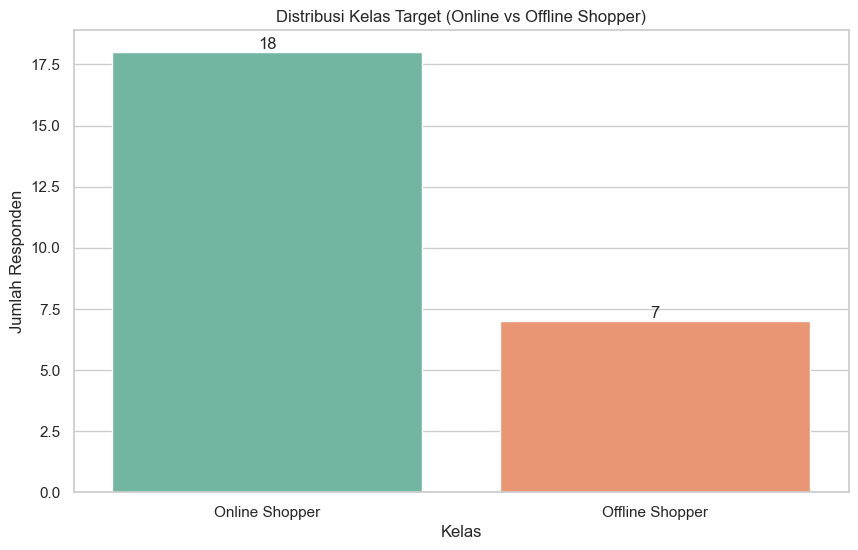

In [11]:
# Visualisasi distribusi target class
class_counts = y.value_counts().reset_index()
class_counts.columns = ['Kelas', 'Jumlah']

ax = sns.barplot(data=class_counts, x='Kelas', y='Jumlah', hue='Kelas', palette='Set2', legend=False)
ax.set_title('Distribusi Kelas Target (Online vs Offline Shopper)')
ax.set_xlabel('Kelas')
ax.set_ylabel('Jumlah Responden')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

## 5. Data Splitting, Encoding, dan Training Naive Bayes
Sel ini membagi data train-test, melakukan encoding fitur kategorikal, lalu melatih model.

In [12]:
# Split data dengan ketentuan Aktivitas 2: 10 data testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10, random_state=42, stratify=y
)

# Pisahkan kolom kategorikal dan numerik secara robust
categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', GaussianNB())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

print(f'Ukuran training set: {X_train.shape[0]}')
print(f'Ukuran testing set: {X_test.shape[0]} (target Aktivitas 2: 10 data)')
print(f'Kolom kategorikal: {categorical_features}')
print(f'Kolom numerik: {numeric_features}')

Ukuran training set: 15
Ukuran testing set: 10 (target Aktivitas 2: 10 data)
Kolom kategorikal: ['Usia']
Kolom numerik: ['Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?', 'Seberapa besar pengaruh "Ulasan/Review Pembeli" terhadap keputusan Anda saat belanja Online?', 'Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?', 'Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?']


## 6. Tabel Perbandingan Prediksi vs Aktual
Sel ini menampilkan hasil prediksi model dibandingkan label sebenarnya pada data testing.

In [13]:
# Tabel perbandingan Prediksi vs Hasil Sebenarnya (10 data testing)
comparison_df = X_test.copy().reset_index(drop=True)
comparison_df['Hasil Sebenarnya'] = y_test.reset_index(drop=True)
comparison_df['Prediksi Model'] = pd.Series(y_pred)
comparison_df['Status'] = np.where(
    comparison_df['Hasil Sebenarnya'] == comparison_df['Prediksi Model'],
    'Benar',
    'Salah'
)

display(comparison_df)

jumlah_benar = (comparison_df['Status'] == 'Benar').sum()
jumlah_total = len(comparison_df)
print(f'Jumlah Prediksi Benar: {jumlah_benar} dari {jumlah_total} data testing')

,Usia,Seberapa sering Anda berbelanja kebutuhan melalui platform Online (E-commerce/Sosmed) dalam sebulan terakhir?,"Seberapa besar pengaruh ""Ulasan/Review Pembeli"" terhadap keputusan Anda saat belanja Online?",Seberapa khawatir Anda terhadap risiko penipuan atau barang tidak sesuai saat belanja Online?,Seberapa penting interaksi langsung dengan penjual/SPG bagi Anda saat berbelanja?,Hasil Sebenarnya,Prediksi Model,Status
0,18-25 Tahun,4,5,3,3,Online Shopper,Online Shopper,Benar
1,<18 Tahun,5,4,5,5,Offline Shopper,Offline Shopper,Benar
2,18-25 Tahun,5,5,5,2,Online Shopper,Online Shopper,Benar
3,18-25 Tahun,4,4,5,4,Online Shopper,Online Shopper,Benar
4,18-25 Tahun,5,4,1,2,Online Shopper,Online Shopper,Benar
5,18-25 Tahun,3,4,5,4,Offline Shopper,Online Shopper,Salah
6,18-25 Tahun,3,5,4,4,Online Shopper,Online Shopper,Benar
7,18-25 Tahun,3,5,5,5,Offline Shopper,Online Shopper,Salah
8,18-25 Tahun,5,5,3,3,Online Shopper,Online Shopper,Benar
9,18-25 Tahun,2,4,4,2,Online Shopper,Online Shopper,Benar


Jumlah Prediksi Benar: 8 dari 10 data testing


## 7. Evaluasi Model dan Visualisasi Metrik
Sel ini menghitung akurasi, confusion matrix, precision, recall, F1-score, dan menampilkan grafik evaluasi.

Akurasi Training: 80.00%
Akurasi Testing : 80.00%
Gap Akurasi (indikasi overfitting): 0.00%


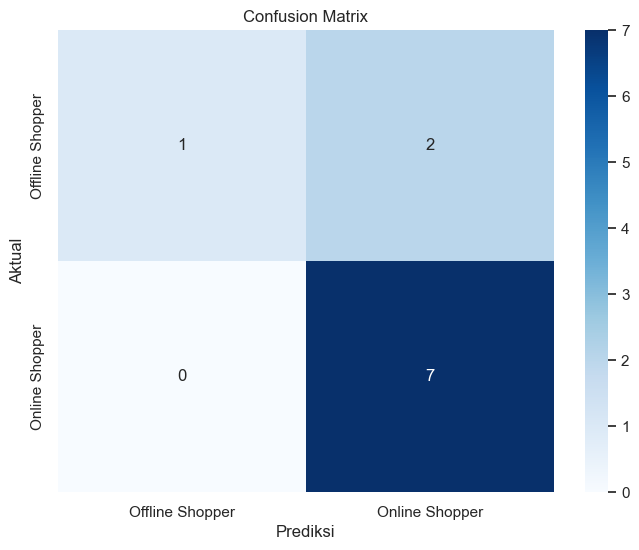

,precision,recall,f1-score,support
Offline Shopper,1.000000,0.333333,0.5000,3.0
Online Shopper,0.777778,1.000000,0.8750,7.0
accuracy,0.800000,0.800000,0.8000,0.8
macro avg,0.888889,0.666667,0.6875,10.0
weighted avg,0.844444,0.800000,0.7625,10.0


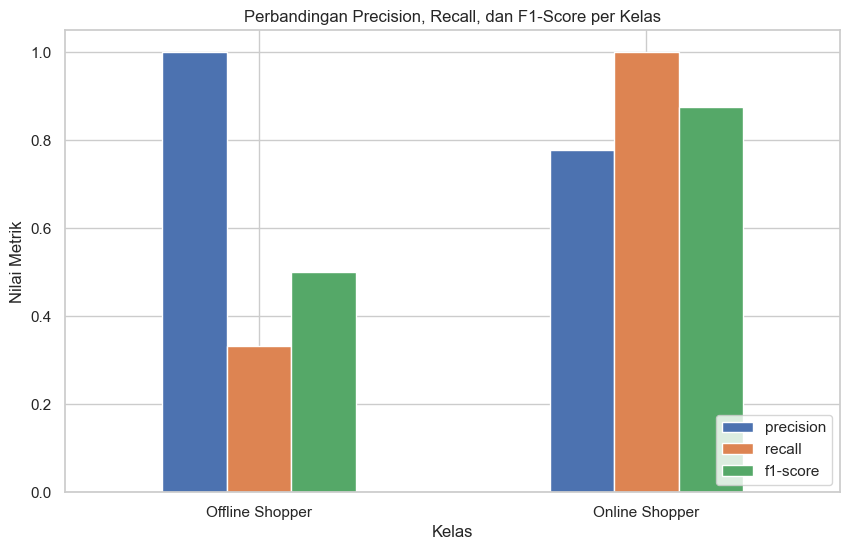


Interpretasi Aktivitas 2:
- Dari 10 data testing, model memprediksi benar sebanyak 8 data.
- Akurasi model pada data testing adalah 80.00%.
- Interpretasi: performa model tergolong baik untuk membedakan Online Shopper dan Offline Shopper pada data uji.


In [14]:
# Evaluasi metrik
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_pred)
gap = train_acc - test_acc

print(f'Akurasi Training: {train_acc * 100:.2f}%')
print(f'Akurasi Testing : {test_acc * 100:.2f}%')
print(f'Gap Akurasi (indikasi overfitting): {gap * 100:.2f}%')

cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
cm_df = pd.DataFrame(cm, index=sorted(y.unique()), columns=sorted(y.unique()))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

metric_rows = [idx for idx in report_df.index if idx not in ['accuracy', 'macro avg', 'weighted avg']]
metric_plot_df = report_df.loc[metric_rows, ['precision', 'recall', 'f1-score']]
metric_plot_df.plot(kind='bar')
plt.title('Perbandingan Precision, Recall, dan F1-Score per Kelas')
plt.xlabel('Kelas')
plt.ylabel('Nilai Metrik')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# Interpretasi Aktivitas 2
print('\nInterpretasi Aktivitas 2:')
print(f'- Dari {jumlah_total} data testing, model memprediksi benar sebanyak {jumlah_benar} data.')
print(f'- Akurasi model pada data testing adalah {test_acc * 100:.2f}%.')

if test_acc >= 0.8:
    print('- Interpretasi: performa model tergolong baik untuk membedakan Online Shopper dan Offline Shopper pada data uji.')
elif test_acc >= 0.6:
    print('- Interpretasi: performa model tergolong cukup, tetapi masih perlu perbaikan fitur/data agar lebih stabil.')
else:
    print('- Interpretasi: performa model masih rendah, perlu perbaikan pada pemilihan fitur dan kualitas data.')

## Kesimpulan Singkat
- Model Naive Bayes telah dilatih untuk memprediksi preferensi belanja Online vs Offline Shopper.
- Evaluasi utama telah ditampilkan: jumlah prediksi benar, akurasi, confusion matrix, precision, recall, dan F1-score.
- Perbandingan akurasi training dan testing digunakan untuk melihat indikasi overfitting.
- Jika gap akurasi kecil, model cenderung cukup baik dalam generalisasi data baru.